# Imports

In [ ]:
from pathlib import Path
import sys
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np

# Filtrer les warnings de matplotlib (clf deprecated)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

cwd = Path.cwd().resolve()
lib_file = next(
    (
        c for c in [
            *[p / "linmodel_lib.py" for p in [cwd, *cwd.parents]],
            *[p / "model_lineaire" / "code" / "py" / "linmodel_lib.py" for p in [cwd, *cwd.parents]],
            *[p / "code" / "py" / "linmodel_lib.py" for p in [cwd, *cwd.parents]],
        ] if c.exists()
    ),
    None,
)
if lib_file is None:
    raise FileNotFoundError("Impossible de trouver linmodel_lib.py")
if str(lib_file.parent) not in sys.path:
    sys.path.insert(0, str(lib_file.parent))

import linmodel_lib
importlib.reload(linmodel_lib)
from linmodel_lib import LinearModel

## Classification

### Linear Simple

In [2]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

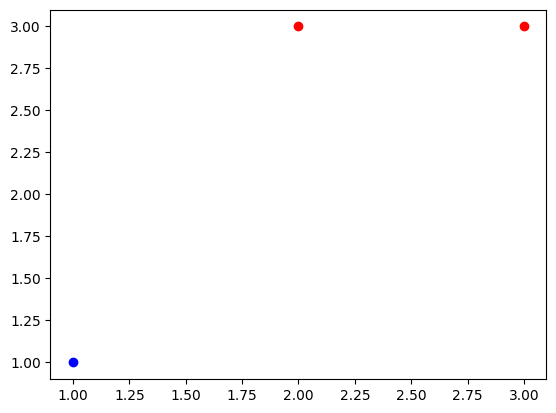

<Figure size 640x480 with 0 Axes>

In [3]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

In [4]:
model = LinearModel([2, 1], learning_rate=0.1, max_ep=1000, classification_algo="rosenblatt")
print("rosenblatt")

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

rosenblatt
Loss finale : 0.386667


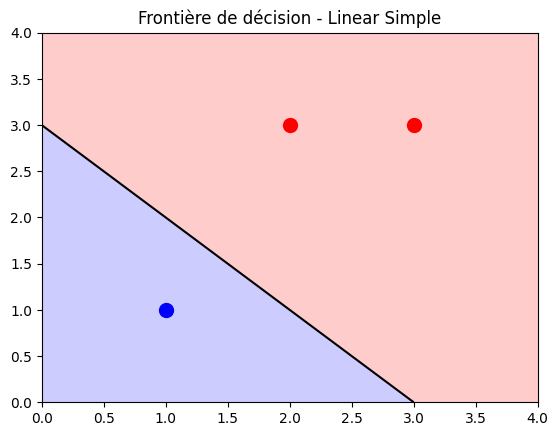

In [5]:
xx, yy = np.meshgrid(np.linspace(0, 4, 300), np.linspace(0, 4, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0, 0], X[0, 1], color='blue', s=100, zorder=5)
plt.scatter(X[1:3, 0], X[1:3, 1], color='red', s=100, zorder=5)
plt.title("Frontière de décision - Linear Simple")
plt.show()

In [6]:
print("Point     | Sortie | Attendu")
print("-" * 35)
for x, exp in zip(X, [1, -1, -1]):
    
    out = model.forward(x)[0]
    print(f"  {x}  ->  {out:+.4f}  (attendu {exp:+d})")


Point     | Sortie | Attendu
-----------------------------------
  [1 1]  ->  +0.2000  (attendu +1)
  [2 3]  ->  -0.4000  (attendu -1)
  [3 3]  ->  -0.6000  (attendu -1)


### Linear Multiple

In [7]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

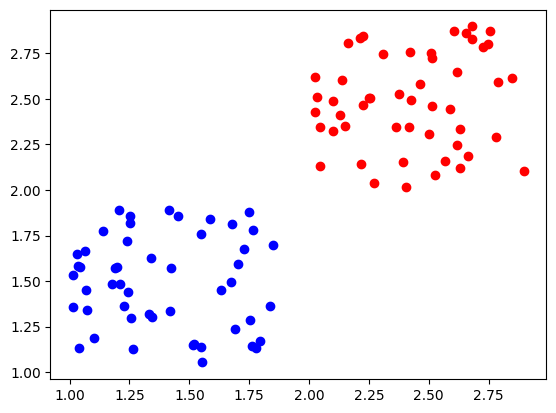

<Figure size 640x480 with 0 Axes>

In [8]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

In [9]:
model = LinearModel([2, 1], learning_rate=0.1, max_ep=1000, classification_algo="rosenblatt")
print("Algo utilisé : rosenblatt")

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Algo utilisé : rosenblatt
Loss finale : 0.470337


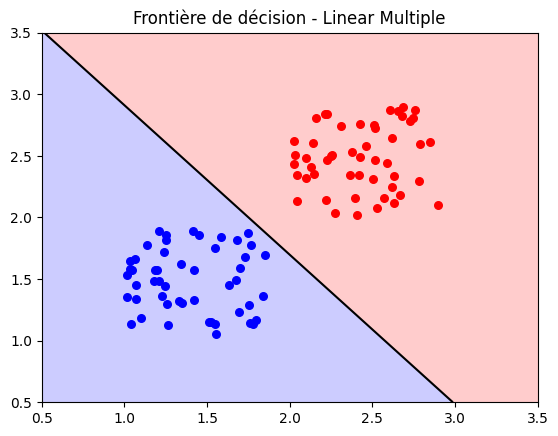

In [10]:
xx, yy = np.meshgrid(np.linspace(0.5, 3.5, 300), np.linspace(0.5, 3.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:50, 0],   X[0:50, 1],   color='blue', s=30, zorder=5)
plt.scatter(X[50:100, 0], X[50:100, 1], color='red',  s=30, zorder=5)
plt.title("Frontière de décision - Linear Multiple")
plt.show()

In [11]:
labels = np.concatenate([np.zeros(50), np.ones(50)]) 
acc = model.accuracy(X, labels)
print(f"Accuracy : {acc * 100:.1f}%")

cm = model.confusion_matrix(X, labels)
print("Matrice de confusion :")
print(cm)

Accuracy : 0.0%
Matrice de confusion :
[[ 0 50]
 [50  0]]


### XOR

In [12]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

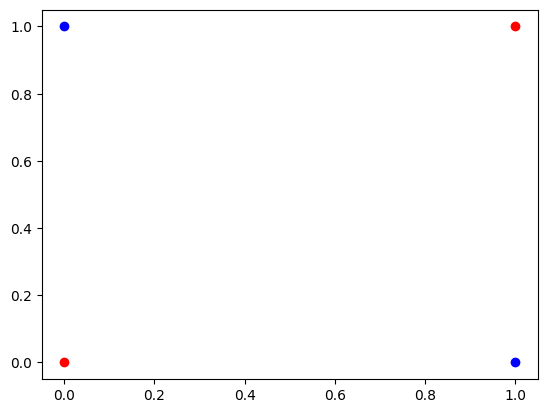

<Figure size 640x480 with 0 Axes>

In [13]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

In [14]:
model = LinearModel([2, 2, 1], learning_rate=0.1, max_ep=1000)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 1.020000


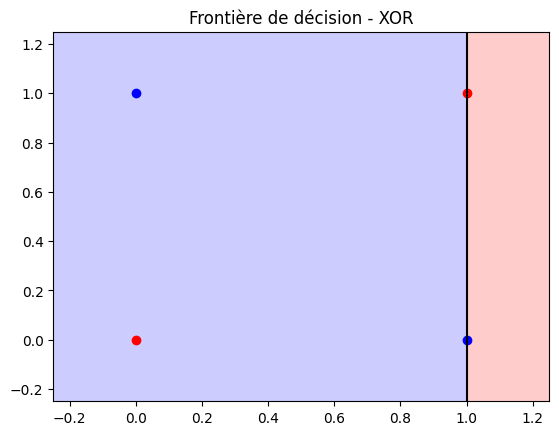

In [15]:
xx, yy = np.meshgrid(np.linspace(-0.25, 1.25, 300), np.linspace(-0.25, 1.25, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.title("Frontière de décision - XOR")
plt.show()


### XOR - avec transformation non linéaire

In [16]:
# Transformation : on ajoute le terme produit x1*x2
def transform_xor(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([x1, x2, x1 * x2])

X_t = transform_xor(X)  # X = le même XOR que juste au-dessus : [[1,0],[0,1],[0,0],[1,1]]
model_xor_t = LinearModel([3, 1], learning_rate=0.1, max_ep=1000)
loss = model_xor_t.train(X_t, Y)
print(f"Loss finale (avec transformation) : {loss:.6f}")

Loss finale (avec transformation) : 0.730000


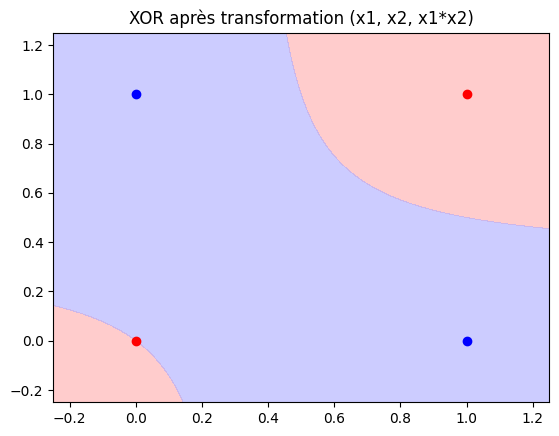

<Figure size 640x480 with 0 Axes>

In [17]:
# Visualisation : on transforme la grille avant de prédire, mais on affiche en (x,y) d'origine
xx, yy = np.meshgrid(np.linspace(-0.25, 1.25, 300), np.linspace(-0.25, 1.25, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_t = transform_xor(grid)
scores = np.array([model_xor_t.forward(pt)[0] for pt in grid_t]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4, 0], X[2:4, 1], color='red')
plt.title("XOR après transformation (x1, x2, x1*x2)")
plt.show()
plt.clf()

### Cross

In [18]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

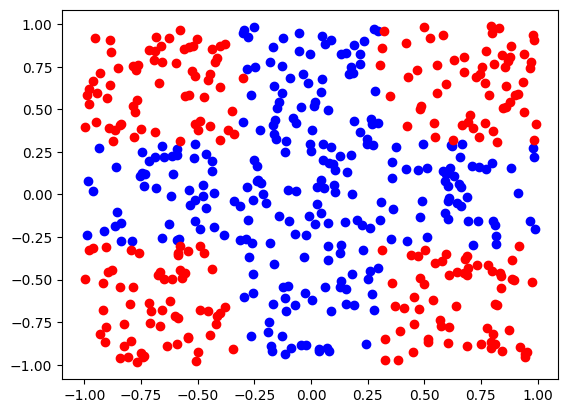

<Figure size 640x480 with 0 Axes>

In [19]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

In [20]:
model = LinearModel([2, 4, 1], learning_rate=0.5, max_ep=10000)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 2.542376


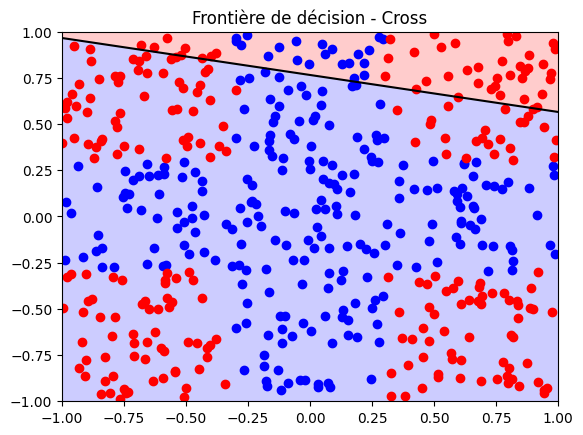

In [21]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.title("Frontière de décision - Cross")
plt.show()


### Multi Linear 3 classes

In [22]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

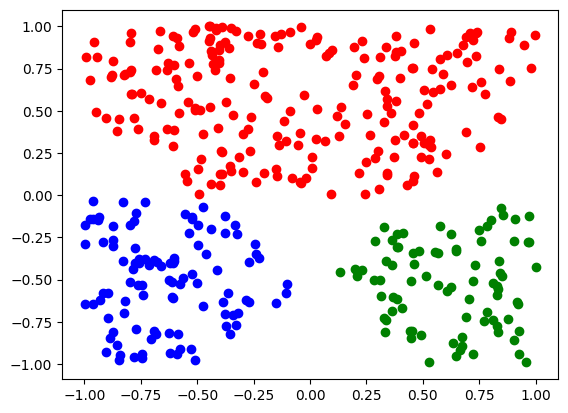

<Figure size 640x480 with 0 Axes>

In [23]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [24]:
model = LinearModel([2, 3], learning_rate=0.5, max_ep=10000, classification_algo="rosenblatt")
print("Algo utilisé : rosenblatt")

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Algo utilisé : rosenblatt
Loss finale : 3.118341


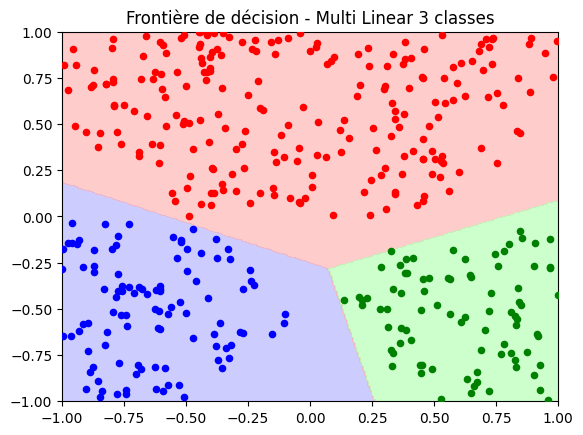

In [25]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = np.array([model.forward(pt) for pt in grid])
classes = np.argmax(preds, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

blue = X[Y[:, 0] == 1]
red = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(blue[:,0], blue[:,1], color='blue', s=20, zorder=5)
plt.scatter(red[:,0], red[:,1], color='red', s=20, zorder=5)
plt.scatter(green[:,0], green[:,1], color='green', s=20, zorder=5)

plt.title("Frontière de décision - Multi Linear 3 classes")
plt.show()

### Multi Cross

In [26]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

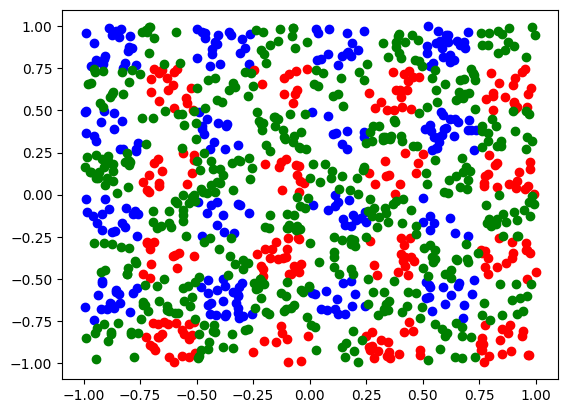

<Figure size 640x480 with 0 Axes>

In [27]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [28]:
model = LinearModel([2, 32, 32, 3], learning_rate=0.01, max_ep=10000)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 0.330974


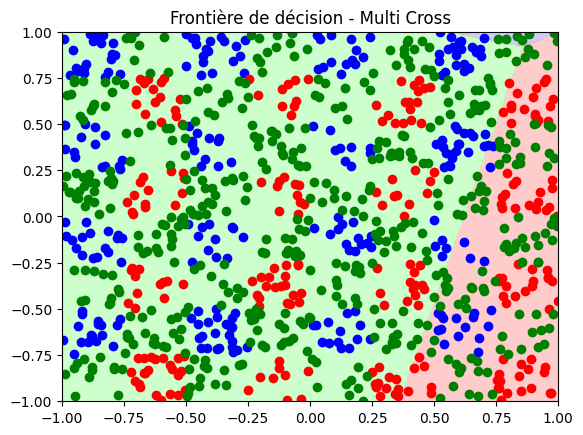

In [29]:
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

preds = np.array([model.forward(pt) for pt in grid])
classes = np.argmax(preds, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5],
             colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

blue = X[Y[:, 0] == 1]
red = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(blue[:,0], blue[:,1], color='blue')
plt.scatter(red[:,0], red[:,1], color='red')
plt.scatter(green[:,0], green[:,1], color='green')

plt.title("Frontière de décision - Multi Cross")
plt.show()

## Régression

### Linear Simple 2D

In [30]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

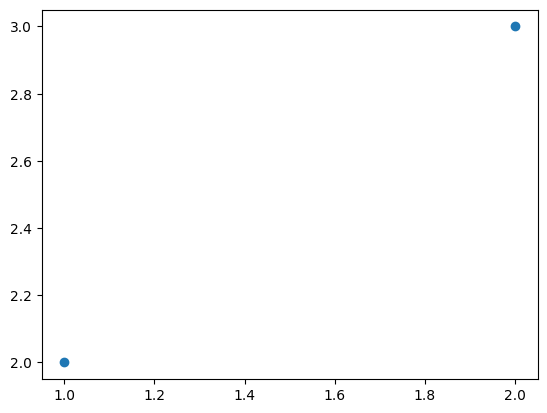

<Figure size 640x480 with 0 Axes>

In [31]:
plt.scatter(X,Y)
plt.show()
plt.clf()

In [32]:
model = LinearModel([1, 1], learning_rate=0.1, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 0.000000


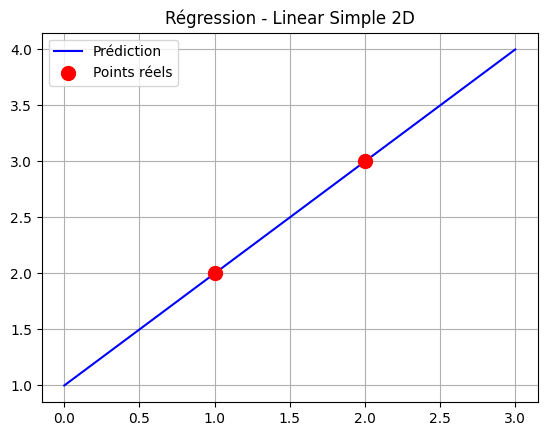

In [33]:
x_range = np.linspace(0, 3, 300).reshape(-1, 1)
y_pred = np.array([model.forward(pt)[0] for pt in x_range])

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')
plt.title("Régression - Linear Simple 2D")
plt.legend(); 
plt.grid(True)
plt.show()

### Non Linear Simple 2D

In [34]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

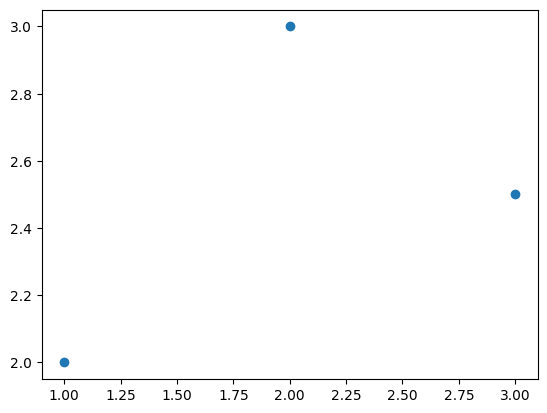

<Figure size 640x480 with 0 Axes>

In [35]:
plt.scatter(X,Y)
plt.show()
plt.clf()

In [36]:
model = LinearModel([1, 4, 1], learning_rate=0.1, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 0.125000


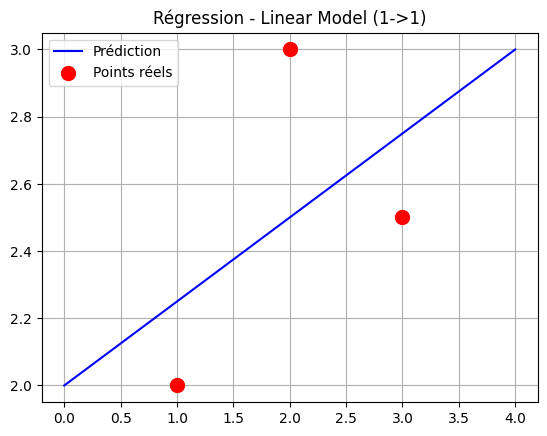

In [37]:
x_range = np.linspace(0, 4, 300).reshape(-1, 1)
y_pred = np.array([model.forward(pt)[0] for pt in x_range])

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')
plt.title("Régression - Linear Model (1->1)")
plt.legend();
plt.grid(True)
plt.show()

### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [38]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

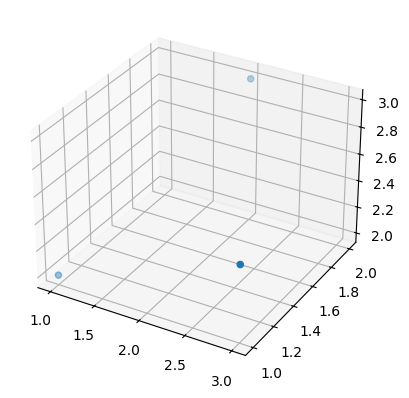

<Figure size 640x480 with 0 Axes>

In [39]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y)
plt.show()
plt.clf()

In [40]:
model = LinearModel([2, 1], learning_rate=0.01, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 0.000000


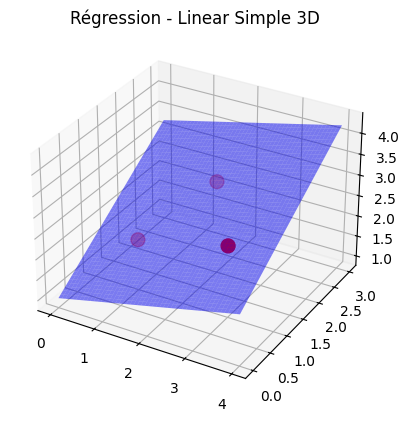

In [41]:
x1_range = np.linspace(0, 4, 50)
x2_range = np.linspace(0, 3, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression - Linear Simple 3D")
plt.show()

### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [42]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

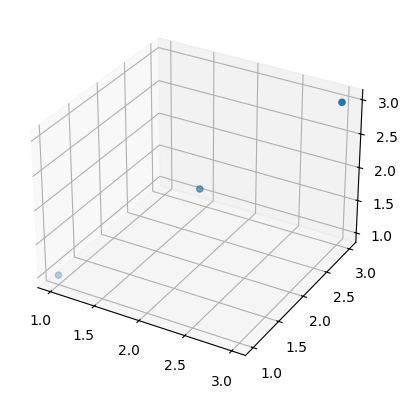

<Figure size 640x480 with 0 Axes>

In [43]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y)
plt.show()
plt.clf()

In [44]:
model = LinearModel([2, 1], learning_rate=0.01, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 4.666667


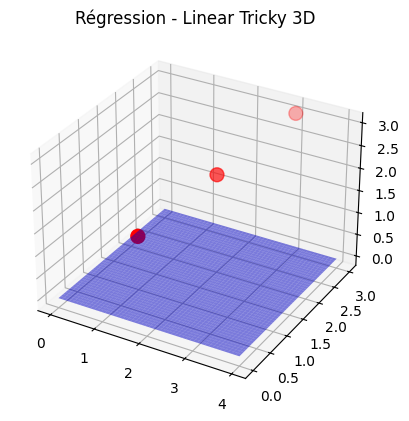

In [45]:
x1_range = np.linspace(0, 4, 50)
x2_range = np.linspace(0, 3, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression - Linear Tricky 3D")
plt.show()

### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [46]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

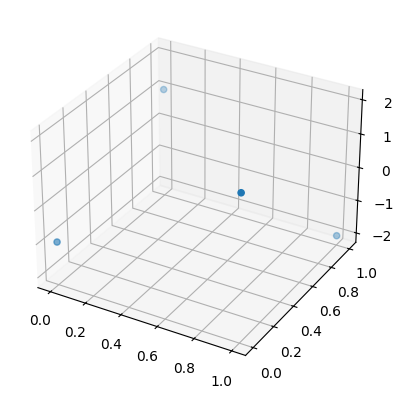

<Figure size 640x480 with 0 Axes>

In [47]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

In [48]:
model = LinearModel([2, 2, 1], learning_rate=0.001, is_regression=True)

loss = model.train(X, Y)
print(f"Loss finale : {loss:.6f}")

Loss finale : 2.250000


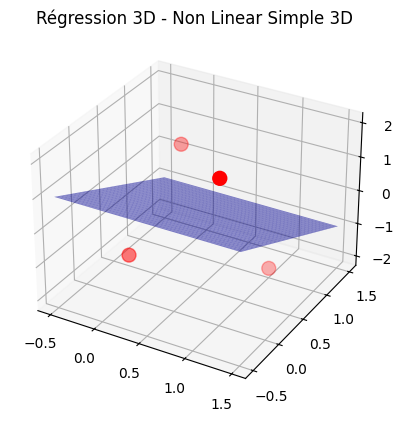

In [49]:
x1_range = np.linspace(-0.5, 1.5, 50)
x2_range = np.linspace(-0.5, 1.5, 50)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
grid = np.c_[xx1.ravel(), xx2.ravel()]

y_pred = np.array([model.forward(pt)[0] for pt in grid]).reshape(xx1.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx1, xx2, y_pred, alpha=0.5, color='blue')
ax.scatter(X[:,0], X[:,1], Y, color='red', s=100, zorder=5, label='Points réels')
ax.set_title("Régression 3D - Non Linear Simple 3D")
plt.show()